## Boundary Attack 

The core idea behind the Boundary Attack is to find adversarial examples that lie very close to the model's decision boundary—the dividing line between different classification regions. Here's a simplified breakdown:

1. Initialization:

- Select a data point (your initial sample) that the model currently classifies correctly.

- Define a distance metric (e.g., L2 distance) to measure how "different" two samples are.

2. Iterative Search:

While the sample is still being classified correctly:
Generate Perturbation: Create a slightly modified version of the sample (potential adversarial example) by adding a small, random disturbance.
Project to Decision Boundary: The key step is to project this perturbed sample back onto the model's decision boundary. This involves finding the closest point on the decision boundary to the perturbed sample. Specialized algorithms and distance calculations are used for this.
Evaluation: The model classifies this projected sample. If it misclassifies it, you've found an adversarial example! If not, proceed to the next iteration.

3. Adversarial Sample: Once the sample is misclassified, the algorithm terminates. This final perturbed sample is the adversarial example.

Interpreting the Results

Adversarial Examples: The attack produces instances that mislead your model despite being subtly different from the original.  Examining these adversarial examples reveals what kinds of changes "break" your model's accuracy.

Number of Iterations: The iterations needed to find an adversarial example are a measure of your model's robustness. If it takes a few iterations, the original sample is very near the decision boundary, implying weaker robustness.

Minimal Perturbation: The "size" of the disturbance required to achieve misclassification reveals how sensitive your model is to deviations from the data it was trained on.

Decision Boundaries:  The  Boundary Attack indirectly maps out portions of the model's decision boundaries. Areas, where boundaries lie close to "normal" data, suggest vulnerability.

Important Considerations:

Hyperparameters: Parameters like the initial perturbation size and the maximum number of iterations influence the attack's behavior.
Computational Cost: Projecting a sample onto the decision boundary can be computationally demanding, especially for complex models.

The output of Boundary Attack process demonstrates that the attack was successfully executed across multiple iterations, showing progress through its steps. The final result indicates a significant impact on the model's accuracy against the adversarial examples generated by the attack, with the accuracy dropping to 0.00%.

This outcome suggests that the model is highly vulnerable to the adversarial examples generated by the Boundary Attack. In practice, such a drastic reduction in accuracy highlights the importance of incorporating robustness into machine learning models, especially in applications where security and reliability are critical.

Understanding the Results:
Iterative Process: The Boundary Attack iteratively refines the adversarial examples, attempting to find inputs that are close to the decision boundary of the classifier but are classified incorrectly. The progress logs show how the attack evolves over iterations.

- Iterative Process: The Boundary Attack iteratively refines the adversarial examples, attempting to find inputs that are close to the decision boundary of the classifier but are classified incorrectly. The progress logs show how the attack evolves over iterations.

- Effectiveness of the Attack: The fact that accuracy on adversarial examples drops to 0.00% indicates that the attack was able to find inputs that led the model to make incorrect predictions for every adversarial example it tested. This underscores the effectiveness of the Boundary Attack in exploiting the model's vulnerabilities.

- Implications: Such vulnerability to adversarial attacks emphasizes the need for defensive measures, such as adversarial training, input validation, or model hardening techniques, to improve the resilience of machine learning models.

Effectiveness of the Attack: The fact that accuracy on adversarial examples drops to 0.00% indicates that the attack was able to find inputs that led the model to make incorrect predictions for every adversarial example it tested. This underscores the effectiveness of the Boundary Attack in exploiting the model's vulnerabilities.

Implications: Such vulnerability to adversarial attacks emphasizes the need for defensive measures, such as adversarial training, input validation, or model hardening techniques, to improve the resilience of machine learning models.

Next Steps:
Given the effectiveness of the Boundary Attack in this scenario, consider the following steps to enhance model robustness:

- Adversarial Training: Incorporate adversarial examples into the training process to improve the model's ability to generalize from them.

- Defensive Distillation: Use techniques like defensive distillation to reduce the model's sensitivity to small perturbations in the input space.

- Feature Squeezing: Simplify the inputs to reduce the degrees of freedom available to an attacker, making it harder to find effective perturbations.

- Regularization Techniques: Implement regularization techniques that encourage the model to learn more robust features, potentially improving its resilience to adversarial manipulation.

- Model Evaluation: Regularly evaluate the model's performance against a variety of adversarial attack techniques to understand its vulnerabilities and improve its defenses.

This scenario highlights the critical role of security considerations in machine learning development, especially for applications where adversarial attacks can have significant consequences.

### Plotting the change in the adversarial samples to achieve minimal perturbation 

TODO:

1. Increasing/Decreasing the epochs.

2. Increasing/Decreasing the num_samples. 

In [ ]:
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import BoundaryAttack
import numpy as np
import matplotlib.pyplot as plt
import copy 
# Wrap the TensorFlow model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(X_train.shape[1],),
    clip_values=(np.min(X_train), np.max(X_train)),
    loss_object=tf.keras.losses.CategoricalCrossentropy()
)
max_iter = 5
# Initialize the Boundary Attack
attack = BoundaryAttack(estimator=classifier, targeted=False, max_iter=max_iter,delta = 0.000001, verbose=True,step_adapt=0.001)

# Select a small sample from the test set for demonstration
sample_index = 10
x_test_sample = X_test[:sample_index]
y_test_sample = y_test[:sample_index]

# Lists to store perturbations, adversarial examples, and accuracies
perturbations = []
adversarial_examples = []
accuracies = []

# Perform the attack iteratively
x_adv = copy.deepcopy(x_test_sample)
for i in range(20):  # Adjust the number of iterations as needed
    x_adv = attack.generate(x=x_adv)
    perturbations.append(np.copy(x_adv - x_test_sample))
    adversarial_examples.append(np.copy(x_adv))
    
    # Evaluate model accuracy on the current adversarial examples
    preds = np.argmax(classifier.predict(x_adv), axis=1)
    accuracy = np.mean(preds == y_test)
    accuracies.append(accuracy)

# Compute L2 norms of perturbations
l2_norms = [np.linalg.norm(pert) for pert in perturbations]
linf_norms = [np.max(np.abs(pert)) for pert in perturbations]


Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 91.51it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 83.85it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 77.79it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 63.95it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 89.11it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 94.68it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 98.55it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 112.89it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 82.39it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 82.53it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 94.91it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 82.79it/s]

Boundary attack - iterations: 100%|██████████| 5/5 [00:00<00:00, 111.19it/s

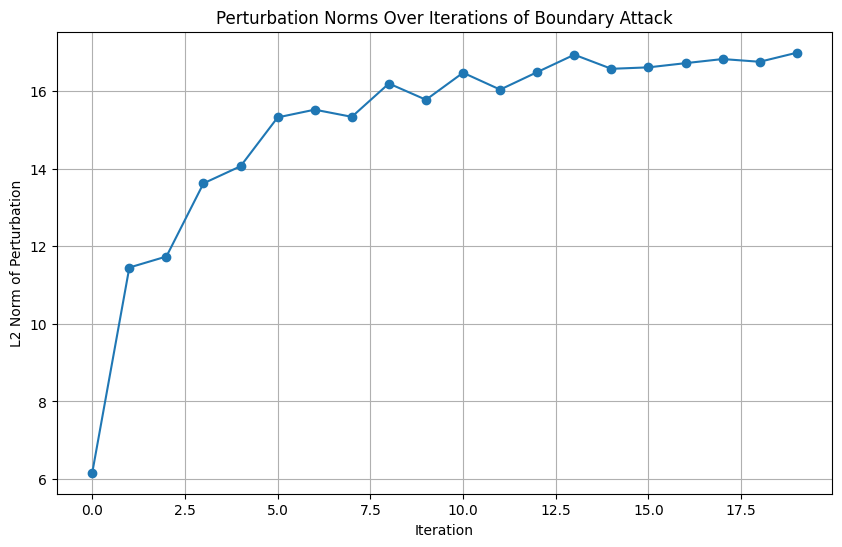

In [ ]:
iterations = list(range(len(l2_norms)))

plt.figure(figsize=(10, 6))
plt.plot(iterations, l2_norms, marker='o')
plt.title('Perturbation Norms Over Iterations of Boundary Attack')
plt.xlabel('Iteration')
plt.ylabel('L2 Norm of Perturbation')
plt.grid(True)
plt.show()


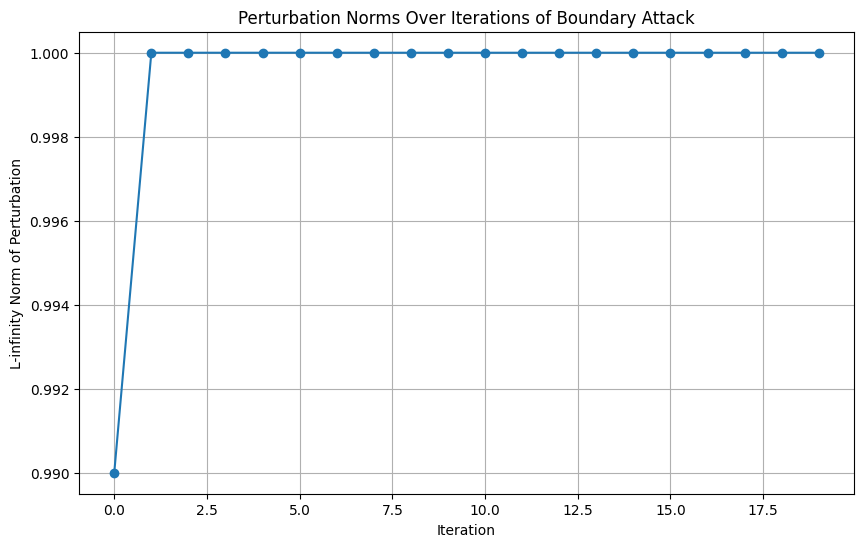

In [ ]:
iterations = list(range(len(linf_norms)))

plt.figure(figsize=(10, 6))
plt.plot(iterations, linf_norms, marker='o')
plt.title('Perturbation Norms Over Iterations of Boundary Attack')
plt.xlabel('Iteration')
plt.ylabel('L-infinity Norm of Perturbation')
plt.grid(True)
plt.show()


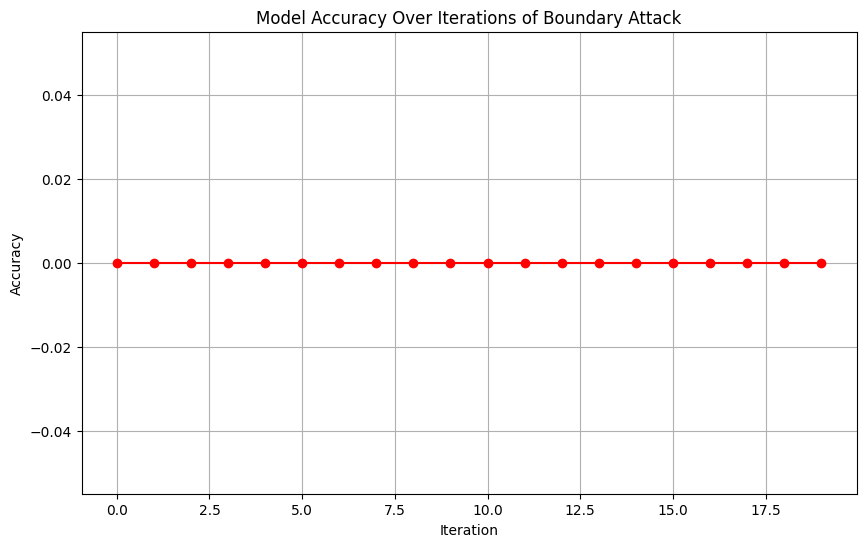

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(iterations, accuracies, marker='o', color='red')
plt.title('Model Accuracy Over Iterations of Boundary Attack')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


Key Observations
1. Decreasing L2 Norms:

Expected Observation: You should see the L2 norms of the perturbations decreasing over iterations.
Implication: This indicates that the Boundary Attack is successfully finding smaller and more minimal perturbations that still manage to fool the classifier. The attack is effectively optimizing to find the least intrusive changes to the input data.


Plateauing of L2 Norms:

Expected Observation: After a certain number of iterations, the L2 norms may start to plateau or decrease very slowly.
Implication: This suggests that the attack has approached the optimal perturbation, and further iterations are making only marginal improvements. The attack has likely found a perturbation close to the minimum required to misclassify the input.\


Sudden Drops or Increases:

Unexpected Observation: If there are sudden drops or increases in the L2 norms, it could indicate instability or issues in the attack process.
Implication: This might suggest that the attack is not converging properly or that there are issues with the gradient estimation or the input data. It might require further investigation into the attack's implementation or parameters.


Example Interpretation
Consider the following hypothetical plot:

Initial Iterations: The L2 norm is relatively high, indicating large perturbations.
Middle Iterations: There is a steady decrease in the L2 norm, showing the attack's effectiveness in reducing perturbation size while maintaining its adversarial nature.
Later Iterations: The curve starts to flatten, indicating diminishing returns on further reducing perturbations.


Practical Insights
Attack Efficiency: If the L2 norms decrease significantly in early iterations, the attack is efficient, quickly finding effective perturbations.
Convergence Behavior: The rate at which the L2 norms plateau can give insights into how many iterations are sufficient for the attack to converge. This can help in setting an appropriate max_iter value for future attacks.
Model Robustness: A steep initial decrease might indicate the model's vulnerability to adversarial attacks, suggesting that the model is not robust and could benefit from adversarial training or other robustness-enhancing techniques.


In [ ]:
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import CarliniL2Method
import numpy as np
import tensorflow as tf

# Wrap the TensorFlow model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(X_train.shape[1],),
    clip_values=(np.min(X_train), np.max(X_train)),
    loss_object=tf.keras.losses.CategoricalCrossentropy()
)

# Initialize the Carlini & Wagner L2 attack with adjusted parameters
attack = CarliniL2Method(
    classifier=classifier,
    targeted=False,
    confidence=0.2,      # Increase confidence to strengthen the attack
    learning_rate=0.01,  # Maintain a small learning rate
    max_iter=50,         # Increase iterations to allow more optimization steps
    verbose=True
)

# Select a small sample from the test set for demonstration
sample_index = 10
x_test_sample = X_test[:sample_index]
y_test_sample = y_test[:sample_index]

# Generate adversarial examples
x_test_adv = attack.generate(x=x_test_sample, y=y_test_sample)

# Evaluate the model on the adversarial examples
loss, accuracy = model.evaluate(x_test_adv, y_test_sample, verbose=0)
print(f"Accuracy on adversarial examples: {accuracy*100:.2f}%")


C&W L_2: 100%|██████████| 10/10 [01:46<00:00, 10.67s/it]Accuracy on adversarial examples: 100.00%



### Performing Adversarial Training to make the model generalize better on the adversarial samples. 

In [ ]:
combined_data = np.concatenate((clean_data, adversarial_examples))
combined_labels = np.concatenate((labels, labels))  # Assuming adversarial labels are the same


### To increase/decrease the number of epochs and the number of samples

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 127.58it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 114.94it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 125.39it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 145.18it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 162.99it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 110.68it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 80.08it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 139.16it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 136.70it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 113.00it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 115.93it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 124.72it/s]

Boundary attack - iterations: 100%|██████

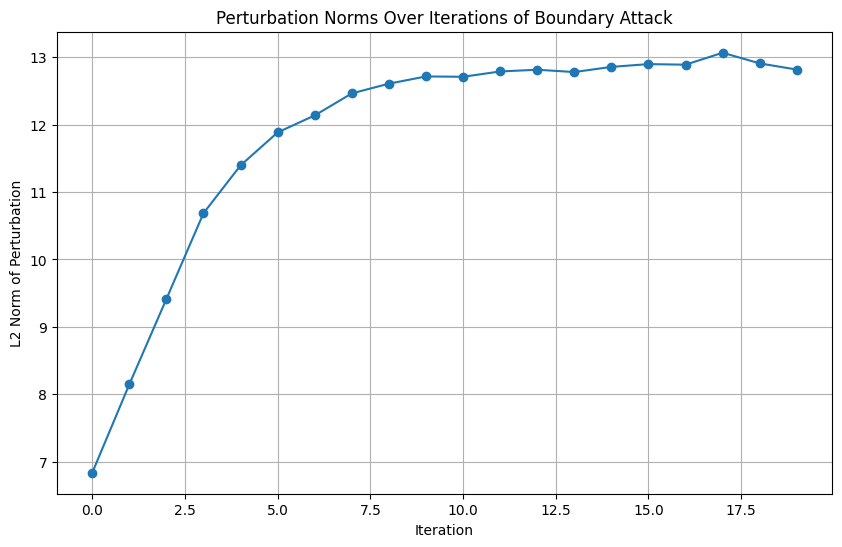

In [ ]:
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import BoundaryAttack
import numpy as np
import matplotlib.pyplot as plt
import copy 

# Wrap the TensorFlow model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(X_train.shape[1],),
    clip_values=(np.min(X_train), np.max(X_train)),
    loss_object=tf.keras.losses.CategoricalCrossentropy()
)

# Parameters for number of iterations and sample size
max_iter = 10  # increase/decrease this value
sample_index = 10  # increase/decrease this value

# Initialize the Boundary Attack
attack = BoundaryAttack(estimator=classifier, targeted=False, max_iter=max_iter, verbose=True)

# Select a small sample from the test set for demonstration
x_test_sample = X_test[:sample_index]
y_test_sample = y_test[:sample_index]

# Lists to store perturbations, adversarial examples, and accuracies
perturbations = []
adversarial_examples = []
accuracies = []

# Perform the attack iteratively
x_adv = copy.deepcopy(x_test_sample)
for i in range(20):  # Adjust the number of iterations as needed
    x_adv = attack.generate(x=x_adv)
    perturbations.append(np.copy(x_adv - x_test_sample))
    adversarial_examples.append(np.copy(x_adv))
    
    # Evaluate model accuracy on the current adversarial examples
    preds = np.argmax(classifier.predict(x_adv), axis=1)
    accuracy = np.mean(preds == y_test_sample)  # Corrected to y_test_sample
    accuracies.append(accuracy)

# Compute L2 norms of perturbations
l2_norms = [np.linalg.norm(pert) for pert in perturbations]

# Plotting the results
iterations = list(range(len(l2_norms)))

plt.figure(figsize=(10, 6))
plt.plot(iterations, l2_norms, marker='o')
plt.title('Perturbation Norms Over Iterations of Boundary Attack')
plt.xlabel('Iteration')
plt.ylabel('L2 Norm of Perturbation')
plt.grid(True)
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=82fc1969-7ff0-4344-a3e7-65ed95a291e5' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>